# Conflict Serializability Checker

Determines whether a transaction schedule is **conflict serializable** by
building a **precedence (serialization) graph** and checking it for cycles.

**Rule:** two operations *conflict* if they (1) belong to different
transactions, (2) access the same data item, and (3) at least one of them is
a write. For each conflicting pair `op1` (from `Ti`) occurring before `op2`
(from `Tj`) in the schedule, we add an edge `Ti -> Tj`.

The schedule is conflict serializable **iff the precedence graph is acyclic**.
If acyclic, any topological sort gives an equivalent serial order.

**How to use this notebook:** run the *Setup* and *Core logic* cells once,
then either call `analyze_schedule("...")` directly with a schedule string
(see *Usage* below), or upload a `.txt` schedule file through the file
picker in *Load a schedule from a file*. Both paths run the same 5-step
analysis: input schedule, schedule table, conflict edges, precedence graph,
and the serializability verdict.

## Setup

Run once per session. Loads the libraries used throughout: `networkx` to
represent and analyze the precedence graph, `matplotlib` to draw it,
`pandas` to render the schedule table, and `re` for parsing the schedule
text.

In [1]:
import re
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Core logic

Parses the schedule and implements the graph algorithm itself:
`build_precedence_graph` (**Step 1** — construct the directed conflict
graph from every conflicting pair of operations) and `find_cycle`
(**Step 2** — detect a cycle in that graph via depth-first search).
`equivalent_serial_order` is a topological sort used to report a valid
execution order whenever the schedule turns out to be serializable.

In [2]:
class Operation:
    """A single read/write operation in a schedule."""
    __slots__ = ("op_type", "txn", "item", "index")

    def __init__(self, op_type, txn, item, index):
        self.op_type = op_type  # 'R' or 'W'
        self.txn = txn
        self.item = item
        self.index = index

    def __repr__(self):
        return f"{self.op_type}{self.txn}({self.item})"


_OP_PATTERN = re.compile(r"^([RWrw])\s*(\d+)\s*\(\s*([A-Za-z0-9_]+)\s*\)$")
_TXN_ONLY_PATTERN = re.compile(r"^([A-Za-z]+)\s*(\d+)$")


def parse_schedule(text):
    """Parse a schedule string like 'R1(A) W1(B) R2(B) W2(A)' into Operations.
    Commit/abort tokens (C1, A2, ...) are recognized and skipped."""
    # Normalize away whitespace *inside* an operation's parentheses first, so
    # forms like "R1 ( A )" or "R1( A)" tokenize the same as "R1(A)" instead
    # of being split into separate, unparseable tokens. Only whitespace that
    # sits between a transaction digit and "(", right after "(", or right
    # before ")" is removed - whitespace that separates two operations
    # (e.g. the space in "R1(A) R1(A)") is left untouched.
    normalized = re.sub(r"(\d)\s+\(", r"\1(", text)
    normalized = re.sub(r"\(\s+", "(", normalized)
    normalized = re.sub(r"\s+\)", ")", normalized)
    tokens = [t for t in re.split(r"[,\s]+", normalized.strip()) if t]
    if not tokens:
        raise ValueError("No operations found in schedule.")

    ops = []
    for token in tokens:
        m = _OP_PATTERN.match(token)
        if m:
            op_type, txn, item = m.group(1).upper(), int(m.group(2)), m.group(3).upper()
            ops.append(Operation(op_type, txn, item, len(ops)))
            continue
        m2 = _TXN_ONLY_PATTERN.match(token)
        if m2 and m2.group(1).upper() in ("C", "COMMIT", "A", "ABORT"):
            continue
        raise ValueError(f"Could not parse operation '{token}' (expected R1(A) or W2(B)).")

    if not ops:
        raise ValueError("No read/write operations found.")
    return ops

In [3]:
def build_precedence_graph(operations):
    """Build the precedence graph. Returns:
       - G: a networkx.DiGraph with one edge per (Ti, Tj) pair, storing the
            set of conflicting data items as an edge attribute
       - edge_list: ordered list of (Ti, Tj, item, op_i, op_j) — one row per
                    distinct conflicting operation pair, matching a manual
                    "list down the conflicts" step
    """
    by_item = defaultdict(list)
    for op in operations:
        by_item[op.item].append(op)

    txns = sorted({op.txn for op in operations})
    G = nx.DiGraph()
    G.add_nodes_from(txns)

    edge_list = []
    seen_triples = set()

    for item, ops in by_item.items():
        ops_sorted = sorted(ops, key=lambda o: o.index)
        for i in range(len(ops_sorted)):
            for j in range(i + 1, len(ops_sorted)):
                op1, op2 = ops_sorted[i], ops_sorted[j]
                if op1.txn == op2.txn:
                    continue
                if op1.op_type == "R" and op2.op_type == "R":
                    continue  # read-read is not a conflict
                triple = (op1.txn, op2.txn, item)
                if triple in seen_triples:
                    continue
                seen_triples.add(triple)
                edge_list.append((op1.txn, op2.txn, item, op1, op2))

                if G.has_edge(op1.txn, op2.txn):
                    G[op1.txn][op2.txn]["items"].add(item)
                else:
                    G.add_edge(op1.txn, op2.txn, items={item})

    return G, edge_list

In [4]:
def find_cycle(G):
    """Return a cycle (list of txn ids) if one exists, else None."""
    try:
        cycle_edges = nx.find_cycle(G, orientation="original")
    except nx.NetworkXNoCycle:
        return None
    nodes = [cycle_edges[0][0]] + [e[1] for e in cycle_edges]
    return nodes


def equivalent_serial_order(G):
    """Topological sort -> an equivalent serial transaction order."""
    return list(nx.topological_sort(G))

## `analyze_schedule` — all 5 steps in one call

Give it a schedule string (`R1(A)`, `W2(B)`, ... separated by commas or
whitespace; `C1`/`A1` commit/abort markers are allowed and ignored) and it
runs and prints/plots **Steps 1-5 together** as a single combined output:

1. the parsed input schedule
2. the schedule table (one column per transaction)
3. the list of conflicting-pair precedence edges
4. the precedence graph, drawn with the cycle highlighted in red if one
   exists (**Step 3** of the assignment)
5. the conclusion — serializable + equivalent order, or not serializable + cycle

In [6]:
def analyze_schedule(schedule_text, figsize=(3.5, 3.5)):
    # --- Step 1: input schedule ---------------------------------------
    operations = parse_schedule(schedule_text)
    print("Step 1 — Input schedule")
    print("S =", " ".join(repr(op) for op in operations))
    print()

    # --- Step 2: schedule table -----------------------------------------
    txns = sorted({op.txn for op in operations})
    rows = [
        {f"T{t}": (repr(op) if op.txn == t else "") for t in txns}
        for op in operations
    ]
    table = pd.DataFrame(rows, columns=[f"T{t}" for t in txns])
    print("Step 2 — Schedule table")
    display(table)
    print()

    # --- Step 3: conflicting pairs -> precedence edges -------------------
    G, edge_list = build_precedence_graph(operations)
    print("Step 3 — Conflicting pairs -> precedence edges")
    if edge_list:
        for a, b, item, op1, op2 in edge_list:
            print(f"  T{a} -> T{b}   ({item}: {op1} before {op2})")
    else:
        print("  (no conflicts; graph has no edges)")
    print()

    # --- Step 4: draw the precedence graph -------------------------------
    cycle = find_cycle(G)
    cycle_edges = set()
    if cycle:
        cycle_edges = {(cycle[i], cycle[i + 1]) for i in range(len(cycle) - 1)}

    print("Step 4 — Precedence (serialization) graph")
    pos = nx.circular_layout(G)
    fig, ax = plt.subplots(figsize=figsize)
    edge_colors = ["#d64550" if (u, v) in cycle_edges else "#6b2d91" for u, v in G.edges()]
    edge_widths = [3 if (u, v) in cycle_edges else 1.5 for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=600, node_color="#6b2d91")
    nx.draw_networkx_labels(G, pos, ax=ax, labels={t: f"T{t}" for t in G.nodes()}, font_color="white", font_size=9)
    nx.draw_networkx_edges(
        G, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
        arrowsize=12, connectionstyle="arc3,rad=0.15", min_source_margin=12, min_target_margin=12
    )
    edge_labels = {(u, v): ", ".join(sorted(d["items"])) for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels, font_size=8)
    # Curved edges (connectionstyle="arc3") are only drawn correctly under an
    # equal aspect ratio; without this, matplotlib's autoscale can badly
    # under-estimate the plot bounds and squash the whole graph into a
    # corner of the figure.
    ax.margins(0.3)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title("Precedence (serialization) graph", fontsize=11)
    ax.axis("off")
    fig.tight_layout()
    plt.show()

    # --- Step 5: conclusion ----------------------------------------------
    print("Step 5 — Conclusion")
    if cycle:
        cycle_str = " -> ".join(f"T{t}" for t in cycle)
        print("Result: NOT CONFLICT SERIALIZABLE")
        print(f"The precedence graph has a cycle: {cycle_str}")
        return {"serializable": False, "cycle": cycle, "graph": G}
    else:
        order = equivalent_serial_order(G)
        order_str = " -> ".join(f"T{t}" for t in order)
        print("Result: CONFLICT SERIALIZABLE")
        print("The precedence graph has no cycle.")
        print(f"Equivalent serial order: {order_str}")
        return {"serializable": True, "order": order, "graph": G}

## Usage

Call `analyze_schedule` with a schedule string — one call, one combined
output. The example below reproduces the in-class example (transactions
T1, T2, T3 operating on items x, y, z).

Step 1 — Input schedule
S = W2(X) W1(X) R3(X) R1(X) W2(Y) R3(Y) R3(Z) R2(X)

Step 2 — Schedule table


,T1,T2,T3
0,,W2(X),
1,W1(X),,
2,,,R3(X)
3,R1(X),,
4,,W2(Y),
5,,,R3(Y)
6,,,R3(Z)
7,,R2(X),



Step 3 — Conflicting pairs -> precedence edges
  T2 -> T1   (X: W2(X) before W1(X))
  T2 -> T3   (X: W2(X) before R3(X))
  T1 -> T3   (X: W1(X) before R3(X))
  T1 -> T2   (X: W1(X) before R2(X))
  T2 -> T3   (Y: W2(Y) before R3(Y))

Step 4 — Precedence (serialization) graph


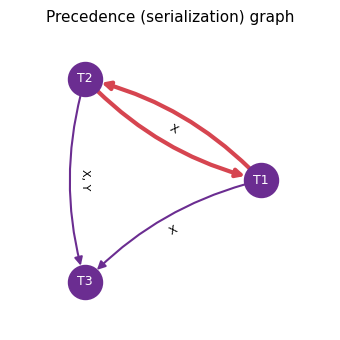

Step 5 — Conclusion
Result: NOT CONFLICT SERIALIZABLE
The precedence graph has a cycle: T1 -> T2 -> T1


In [ ]:
_ = analyze_schedule("W2(x), W1(x), R3(x), R1(x), W2(y), R3(y), R3(z), R2(x)")

## Load a schedule from a file

This is how the notebook satisfies the assignment's "accept input from a
file" requirement. Click **Choose file**, pick a `.txt` file containing a
schedule (operations separated by commas and/or whitespace, e.g.
`R1(A), W1(A), R2(A), W2(A)`), then click **Analyze uploaded file**. Needs
`ipywidgets` (`pip install ipywidgets`); works in both classic Jupyter and
VS Code's notebook UI.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def _make_upload_widget():
    # A brand new FileUpload instance every time works around a known
    # ipywidgets quirk: even with multiple=False, re-selecting a file can
    # ADD to the widget's internal file list instead of replacing it, so
    # the button label keeps growing - "Choose file (1)", then "(2)", then
    # "(3)" - even though only the latest file should count. Resetting
    # .value on the *same* widget instance doesn't reliably fix this in
    # every frontend, so instead we swap in a fresh widget after each use.
    return widgets.FileUpload(accept=".txt", multiple=False, description="Choose file")


_upload = _make_upload_widget()
_run_button = widgets.Button(description="Analyze uploaded file", button_style="primary")
_clear_button = widgets.Button(description="Clear", button_style="")
_output_area = widgets.Output()
_container = widgets.VBox([_upload, widgets.HBox([_run_button, _clear_button]), _output_area])


def _extract_uploaded_text(upload_widget):
    """Return (filename, decoded_text) for the most recently selected file,
    or (None, None) if nothing has been uploaded yet. Handles both the
    ipywidgets 8.x value format (a tuple of dicts) and the older 7.x format
    (a dict keyed by filename, insertion-ordered). Kept defensive (always
    uses the LAST entry) in case a widget instance ever ends up holding
    more than one file despite the fresh-widget workaround above."""
    value = upload_widget.value
    if not value:
        return None, None
    if isinstance(value, dict):  # ipywidgets < 8
        items = list(value.items())
        filename, file_info = items[-1]
        count = len(items)
    else:  # ipywidgets >= 8: tuple of dicts
        file_info = value[-1]
        filename = file_info["name"]
        count = len(value)
    if count > 1:
        print(f"Note: {count} files were attached; using the most recently "
              f"chosen one ({filename!r}).\n")
    content = bytes(file_info["content"])
    return filename, content.decode("utf-8")


def _reset_upload_widget():
    """Swap in a fresh, empty FileUpload widget so the next selection
    always starts from a clean single-file state."""
    global _upload
    _upload = _make_upload_widget()
    _container.children = (_upload, widgets.HBox([_run_button, _clear_button]), _output_area)


def _on_run_clicked(_button):
    with _output_area:
        clear_output()
        filename, text = _extract_uploaded_text(_upload)
        if text is None:
            print("Choose a file first, then click 'Analyze uploaded file'.")
            return
        print(f"Loaded {filename!r}\n")
        analyze_schedule(text)
    _reset_upload_widget()  # ready for a clean next upload


def _on_clear_clicked(_button):
    _reset_upload_widget()
    with _output_area:
        clear_output()
        print("Cleared. Choose a new file to analyze.")


_run_button.on_click(_on_run_clicked)
_clear_button.on_click(_on_clear_clicked)
display(_container)